In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np
import os
from PIL import Image

device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")

class CatDogCustomDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_files = [f for f in os.listdir(root_dir) if f.endswith('.jpg')]

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_name = self.image_files[idx]
        img_path = os.path.join(self.root_dir, img_name)
        image = Image.open(img_path).convert('RGB')
        label = 0 if 'cat' in img_name.lower() else 1
        if self.transform:
            image = self.transform(image)
        return image, label

transform_train = transforms.Compose([
    transforms.Resize((128, 128)), 
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2), 
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
])

transform_test = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
])

full_dataset = CatDogCustomDataset(root_dir = r'C:\Users\User\Downloads\DL_0101\ANN\dogs-vs-cats\train\train', transform=transform_train)
train_size = int(0.85 * len(full_dataset)) 
test_size = len(full_dataset) - train_size
train_data, test_data = random_split(full_dataset, [train_size, test_size])

test_data.dataset.transform = transform_test

train_loader = DataLoader(train_data, batch_size=64, shuffle=True) 
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

classes = ['cat', 'dog']

In [7]:
class CatDog_CNN_Advanced(nn.Module):
    def __init__(self):
        super(CatDog_CNN_Advanced, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.relu3 = nn.ReLU()
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(256)
        self.relu4 = nn.ReLU()
        self.pool4 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dropout = nn.Dropout(0.5)
        self.fc1 = nn.Linear(256 * 8 * 8, 512)
        self.fc2 = nn.Linear(512, 2)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu1(x)
        x = self.pool1(x)
        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu2(x)
        x = self.pool2(x)
        x = self.conv3(x)
        x = self.bn3(x)
        x = self.relu3(x)
        x = self.pool3(x)
        x = self.conv4(x)
        x = self.bn4(x)
        x = self.relu4(x)
        x = self.pool4(x)
        x = x.view(x.size(0), -1) 
        x = self.fc1(x)
        x = torch.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        
        return x

In [8]:
model = CatDog_CNN_Advanced().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-2) 
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=5, factor=0.5)

In [9]:
loss_values, accuracy_values = [], []

for epoch in range(50):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    epoch_acc = 100 * correct / total
    loss_values.append(running_loss / len(train_loader))
    accuracy_values.append(epoch_acc)
    
    scheduler.step(epoch_acc)
    
    print(f"Epoch {epoch+1}/50, Loss: {loss_values[-1]:.4f}, Train Acc: {epoch_acc:.2f}%")

Epoch 1/50, Loss: 0.8368, Train Acc: 65.61%
Epoch 2/50, Loss: 0.4917, Train Acc: 76.62%
Epoch 3/50, Loss: 0.4105, Train Acc: 81.57%
Epoch 4/50, Loss: 0.3613, Train Acc: 84.44%
Epoch 5/50, Loss: 0.3226, Train Acc: 86.40%
Epoch 6/50, Loss: 0.2935, Train Acc: 87.97%
Epoch 7/50, Loss: 0.2576, Train Acc: 89.70%
Epoch 8/50, Loss: 0.2346, Train Acc: 90.47%
Epoch 9/50, Loss: 0.2061, Train Acc: 91.60%
Epoch 10/50, Loss: 0.1917, Train Acc: 92.29%
Epoch 11/50, Loss: 0.1750, Train Acc: 93.05%
Epoch 12/50, Loss: 0.1595, Train Acc: 93.76%
Epoch 13/50, Loss: 0.1347, Train Acc: 94.63%
Epoch 14/50, Loss: 0.1259, Train Acc: 95.04%
Epoch 15/50, Loss: 0.1203, Train Acc: 95.30%
Epoch 16/50, Loss: 0.1032, Train Acc: 95.87%
Epoch 17/50, Loss: 0.0901, Train Acc: 96.41%
Epoch 18/50, Loss: 0.0802, Train Acc: 96.93%
Epoch 19/50, Loss: 0.0677, Train Acc: 97.36%
Epoch 20/50, Loss: 0.0691, Train Acc: 97.34%
Epoch 21/50, Loss: 0.0552, Train Acc: 98.00%
Epoch 22/50, Loss: 0.0578, Train Acc: 97.84%
Epoch 23/50, Loss: 

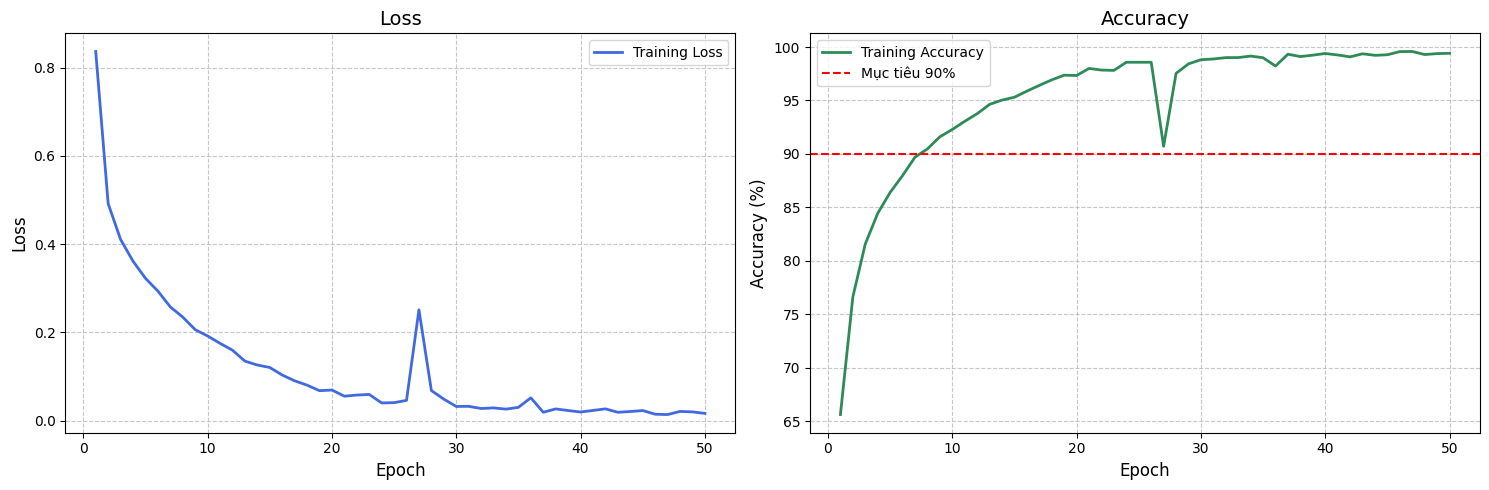

In [10]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, len(loss_values) + 1), loss_values, color='royalblue', linewidth=2, label='Training Loss')
plt.title('Loss', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, len(accuracy_values) + 1), accuracy_values, color='seagreen', linewidth=2, label='Training Accuracy')
plt.axhline(y=90, color='red', linestyle='--', label='Mục tiêu 90%')
plt.title('Accuracy', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

plt.tight_layout()
plt.show()

In [11]:
model.eval()
correct, total = 0, 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_acc = 100 * correct / total
print(f"\n Độ chính xác trên tập test: {test_acc:.2f}%")


 Độ chính xác trên tập test: 92.40%
